# OpenAQ PM2.5 Data Analysis - Extended Dataset (2023-2025)

Analysis of PM2.5 air quality data from OpenAQ for the period June 2023 to June 2025.

**Version**: V4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
data_path = '/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openaq_processed_20230601_to_20250630.csv'
print(f"Loading OpenAQ data from: {data_path}")

df = pd.read_csv(data_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading OpenAQ data from: /Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openaq_processed_20230601_to_20250630.csv
Dataset shape: 9,579,181 rows × 26 columns
Date range: 2023-07-14 16:00:00+00:00 to 2025-07-26 05:00:00+00:00
Memory usage: 3453.2 MB


## 1. Dataset Overview

In [3]:
print("Dataset Info:")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Unique hexagons (res8): {df['h3_index_res8'].nunique():,}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

Dataset Info:
Total records: 9,579,181
Unique hexagons (res8): 643
Date range: 2023-07-14 16:00:00+00:00 to 2025-07-26 05:00:00+00:00

Columns (26):
  - timestamp: datetime64[ns, UTC]
  - h3_index_res8: object
  - co_ppm_mean: float64
  - co_ppm_std: float64
  - co_ppm_min: float64
  - co_ppm_max: float64
  - co_ppm_count: int64
  - no2_ugm3_mean: float64
  - no2_ugm3_std: float64
  - no2_ugm3_min: float64
  - no2_ugm3_max: float64
  - no2_ugm3_count: int64
  - pm25_ugm3_mean: float64
  - pm25_ugm3_std: float64
  - pm25_ugm3_min: float64
  - pm25_ugm3_max: float64
  - pm25_ugm3_count: int64
  - so2_ugm3_mean: float64
  - so2_ugm3_std: float64
  - so2_ugm3_min: float64
  - so2_ugm3_max: float64
  - so2_ugm3_count: int64
  - h3_lat_res8: float64
  - h3_lon_res8: float64
  - data_source: object
  - country: object


In [4]:
print("First 10 rows:")
display(df.head(10))

print("\nLast 10 rows:")
display(df.tail(10))

First 10 rows:


,timestamp,h3_index_res8,co_ppm_mean,co_ppm_std,co_ppm_min,co_ppm_max,co_ppm_count,no2_ugm3_mean,no2_ugm3_std,no2_ugm3_min,no2_ugm3_max,no2_ugm3_count,pm25_ugm3_mean,pm25_ugm3_std,pm25_ugm3_min,pm25_ugm3_max,pm25_ugm3_count,so2_ugm3_mean,so2_ugm3_std,so2_ugm3_min,so2_ugm3_max,so2_ugm3_count,h3_lat_res8,h3_lon_res8,data_source,country
0,2023-07-14 16:00:00+00:00,882e0122e5fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,6.00,NaN,6.00,6.00,1,0.00,NaN,0.00,0.00,1,39.27,141.85,openaq,JP
1,2023-07-14 16:00:00+00:00,882e0165c5fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,10.00,NaN,10.00,10.00,1,0.00,NaN,0.00,0.00,1,39.65,141.95,openaq,JP
2,2023-07-14 16:00:00+00:00,882e0800b3fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,39.76,140.07,openaq,JP
3,2023-07-14 16:00:00+00:00,882e0800ddfffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,39.72,140.10,openaq,JP
4,2023-07-14 16:00:00+00:00,882e0876d3fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,9.00,NaN,9.00,9.00,1,NaN,NaN,NaN,NaN,0,39.89,139.85,openaq,JP
5,2023-07-14 16:00:00+00:00,882e0a1609fffff,0.00,NaN,0.00,0.00,1,0.00,NaN,0.00,0.00,1,15.00,NaN,15.00,15.00,1,NaN,NaN,NaN,NaN,0,40.59,140.48,openaq,JP
6,2023-07-14 16:00:00+00:00,882e0a1b51fffff,NaN,NaN,NaN,NaN,0,0.01,NaN,0.01,0.01,1,5.00,NaN,5.00,5.00,1,NaN,NaN,NaN,NaN,0,40.81,140.74,openaq,JP
7,2023-07-14 16:00:00+00:00,882e0a94d7fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,7.00,NaN,7.00,7.00,1,0.00,NaN,0.00,0.00,1,40.27,140.58,openaq,JP
8,2023-07-14 16:00:00+00:00,882e0c0201fffff,NaN,NaN,NaN,NaN,0,0.01,NaN,0.01,0.01,1,12.00,NaN,12.00,12.00,1,NaN,NaN,NaN,NaN,0,38.93,141.12,openaq,JP
9,2023-07-14 16:00:00+00:00,882e0c0805fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,6.00,NaN,6.00,6.00,1,0.00,NaN,0.00,0.00,1,39.14,141.14,openaq,JP



Last 10 rows:


,timestamp,h3_index_res8,co_ppm_mean,co_ppm_std,co_ppm_min,co_ppm_max,co_ppm_count,no2_ugm3_mean,no2_ugm3_std,no2_ugm3_min,no2_ugm3_max,no2_ugm3_count,pm25_ugm3_mean,pm25_ugm3_std,pm25_ugm3_min,pm25_ugm3_max,pm25_ugm3_count,so2_ugm3_mean,so2_ugm3_std,so2_ugm3_min,so2_ugm3_max,so2_ugm3_count,h3_lat_res8,h3_lon_res8,data_source,country
9579171,2025-07-26 04:00:00+00:00,884b61b829fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,33.40,133.32,openaq,JP
9579172,2025-07-26 04:00:00+00:00,884b64b461fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,34.02,131.55,openaq,JP
9579173,2025-07-26 04:00:00+00:00,884b6cb281fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,8.00,NaN,8.00,8.00,1,NaN,NaN,NaN,NaN,0,33.86,134.50,openaq,JP
9579174,2025-07-26 04:00:00+00:00,884b6cb6b3fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,33.89,134.67,openaq,JP
9579175,2025-07-26 05:00:00+00:00,882e6109c3fffff,0.10,NaN,0.10,0.10,1,0.00,NaN,0.00,0.00,1,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,34.87,135.65,openaq,JP
9579176,2025-07-26 05:00:00+00:00,882e617249fffff,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,6.00,NaN,6.00,6.00,1,NaN,NaN,NaN,NaN,0,34.86,135.60,openaq,JP
9579177,2025-07-26 05:00:00+00:00,882e635035fffff,0.20,NaN,0.20,0.20,1,0.00,NaN,0.00,0.00,1,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,35.96,136.19,openaq,JP
9579178,2025-07-26 05:00:00+00:00,882e6c4111fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,34.76,134.80,openaq,JP
9579179,2025-07-26 05:00:00+00:00,882e748315fffff,NaN,NaN,NaN,NaN,0,0.01,NaN,0.01,0.01,1,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,36.23,139.52,openaq,JP
9579180,2025-07-26 05:00:00+00:00,882f5bd457fffff,NaN,NaN,NaN,NaN,0,0.00,NaN,0.00,0.00,1,6.00,NaN,6.00,6.00,1,NaN,NaN,NaN,NaN,0,35.37,139.38,openaq,JP


## 2. Temporal Coverage Analysis

In [5]:
df['date'] = df['timestamp'].dt.date
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month

all_dates = pd.date_range('2023-06-01', '2025-06-30', freq='D').date
existing_dates = set(df['date'].unique())
missing_dates = sorted(set(all_dates) - existing_dates)

print(f"Temporal Coverage Analysis:")
print("="*60)
print(f"Expected days: {len(all_dates)}")
print(f"Days with data: {len(existing_dates)}")
print(f"Missing days: {len(missing_dates)}")
print(f"Coverage: {len(existing_dates)/len(all_dates)*100:.1f}%")

print(f"\nData starts from: {df['timestamp'].min().date()}")
print(f"Data ends at: {df['timestamp'].max().date()}")

print("\nYearly coverage:")
yearly_counts = df.groupby('year').size()
for year in [2023, 2024, 2025]:
    count = yearly_counts.get(year, 0)
    print(f"  {year}: {count:,} records")

print("\nMonthly coverage by year:")
monthly_counts = df.groupby([df['timestamp'].dt.year, df['timestamp'].dt.month]).size()
for year in [2023, 2024, 2025]:
    print(f"\n{year}:")
    for month in range(1, 13):
        if year == 2023 and month < 6:
            continue
        if year == 2025 and month > 6:
            break
        count = monthly_counts.get((year, month), 0)
        month_name = pd.Timestamp(f'{year}-{month:02d}-01').strftime('%B')
        print(f"  {month_name:10s}: {count:8,} records")

Temporal Coverage Analysis:
Expected days: 761
Days with data: 732
Missing days: 55
Coverage: 96.2%

Data starts from: 2023-07-14
Data ends at: 2025-07-26

Yearly coverage:
  2023: 2,078,211 records
  2024: 4,763,449 records
  2025: 2,737,521 records

Monthly coverage by year:

2023:
  June      :        0 records
  July      :   63,686 records
  August    :  428,782 records
  September :  415,186 records
  October   :  412,710 records
  November  :  373,973 records
  December  :  383,874 records

2024:
  January   :  373,545 records
  February  :  332,256 records
  March     :  367,339 records
  April     :  378,820 records
  May       :  423,766 records
  June      :  407,880 records
  July      :  421,743 records
  August    :  421,054 records
  September :  404,063 records
  October   :  416,445 records
  November  :  399,189 records
  December  :  417,349 records

2025:
  January   :  411,188 records
  February  :  368,004 records
  March     :  410,933 records
  April     :  391,

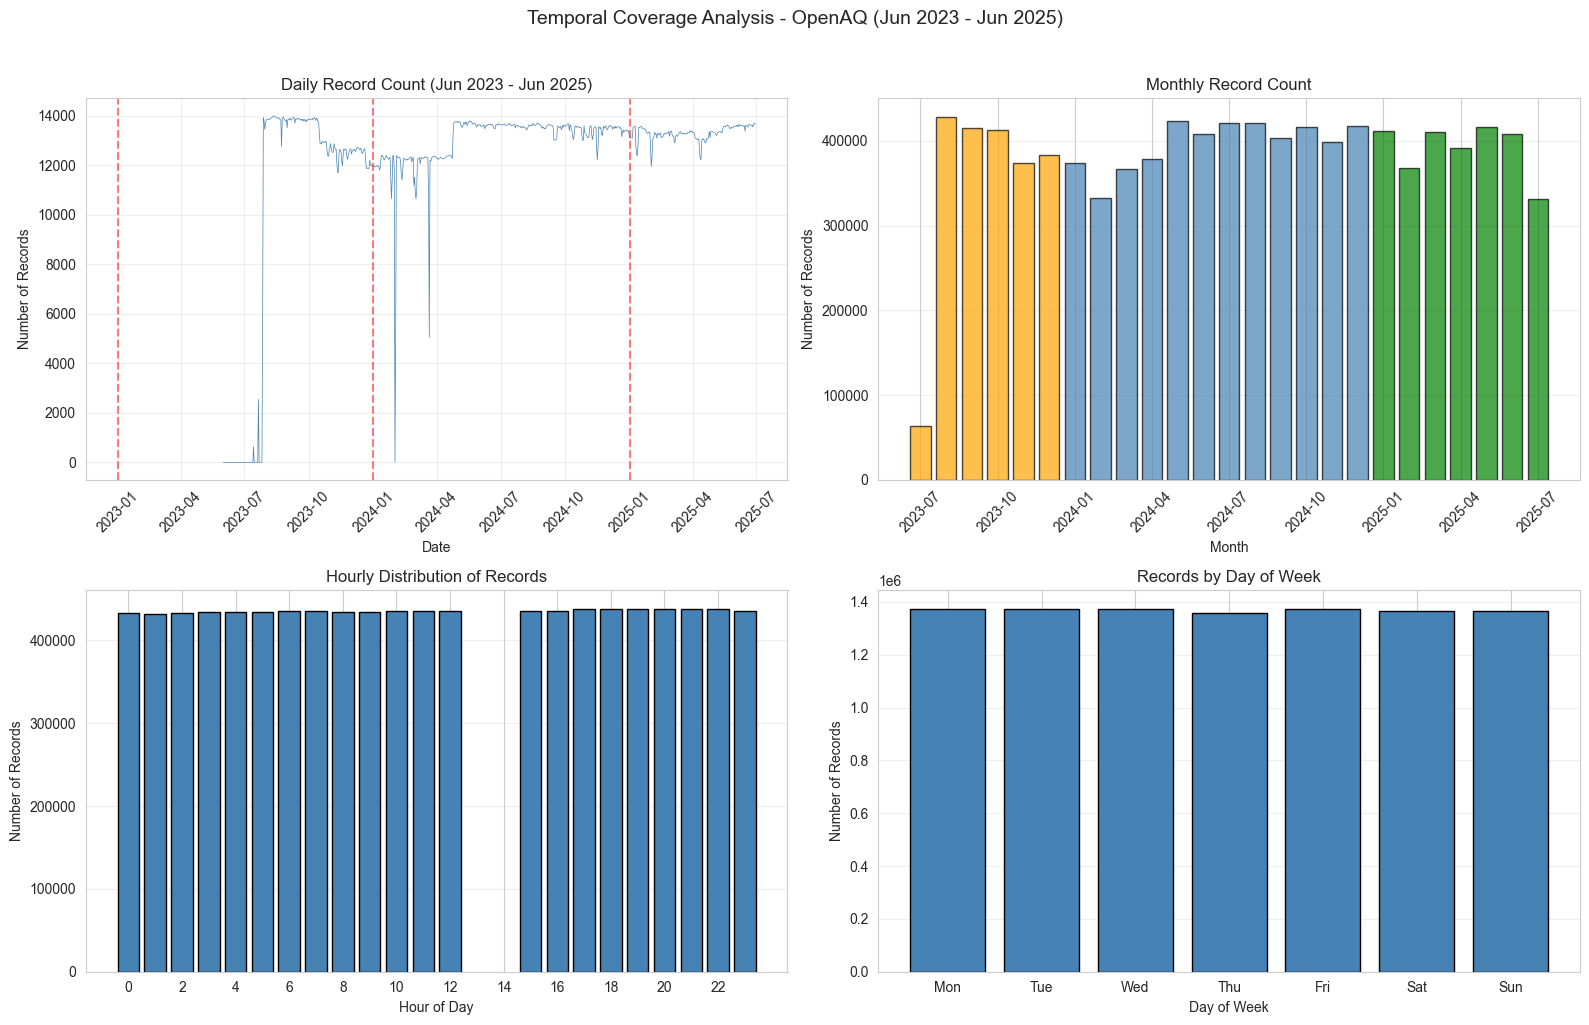

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

daily_counts = df.groupby('date').size().reindex(all_dates, fill_value=0)
axes[0, 0].plot(daily_counts.index, daily_counts.values, linewidth=0.5, color='steelblue')
axes[0, 0].set_title('Daily Record Count (Jun 2023 - Jun 2025)', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

for year in [2023, 2024, 2025]:
    year_start = pd.Timestamp(f'{year}-01-01')
    axes[0, 0].axvline(x=year_start, color='red', linestyle='--', alpha=0.5)

monthly_counts_plot = df.groupby(df['timestamp'].dt.to_period('M')).size()
axes[0, 1].bar(range(len(monthly_counts_plot)), monthly_counts_plot.values, 
               color=['orange' if '2023' in str(idx) else 'steelblue' if '2024' in str(idx) else 'green' 
                      for idx in monthly_counts_plot.index],
               edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Monthly Record Count', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].set_xticks(range(0, len(monthly_counts_plot), 3))
axes[0, 1].set_xticklabels([str(idx) for idx in monthly_counts_plot.index][::3], rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

hourly_counts = df.groupby(df['timestamp'].dt.hour).size()
axes[1, 0].bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Hourly Distribution of Records', fontsize=12)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3, axis='y')

weekday_counts = df.groupby(df['timestamp'].dt.dayofweek).size()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 1].bar(range(7), weekday_counts.reindex(range(7), fill_value=0).values, 
               color='steelblue', edgecolor='black')
axes[1, 1].set_title('Records by Day of Week', fontsize=12)
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(weekday_names)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Temporal Coverage Analysis - OpenAQ (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. PM2.5 Data Analysis

In [7]:
pm25_columns = [col for col in df.columns if 'pm25' in col.lower()]
print(f"PM2.5 columns found: {pm25_columns}")

missing_stats = pd.DataFrame({
    'Missing Count': df[pm25_columns].isnull().sum(),
    'Missing %': (df[pm25_columns].isnull().sum() / len(df) * 100).round(2),
    'Available Count': df[pm25_columns].notnull().sum(),
    'Available %': (df[pm25_columns].notnull().sum() / len(df) * 100).round(2)
})

print("\nPM2.5 Data Completeness:")
print("="*60)
display(missing_stats)

PM2.5 columns found: ['pm25_ugm3_mean', 'pm25_ugm3_std', 'pm25_ugm3_min', 'pm25_ugm3_max', 'pm25_ugm3_count']

PM2.5 Data Completeness:


,Missing Count,Missing %,Available Count,Available %
pm25_ugm3_mean,1917487,20.02,7661694,79.98
pm25_ugm3_std,9558902,99.79,20279,0.21
pm25_ugm3_min,1917487,20.02,7661694,79.98
pm25_ugm3_max,1917487,20.02,7661694,79.98
pm25_ugm3_count,0,0.00,9579181,100.00


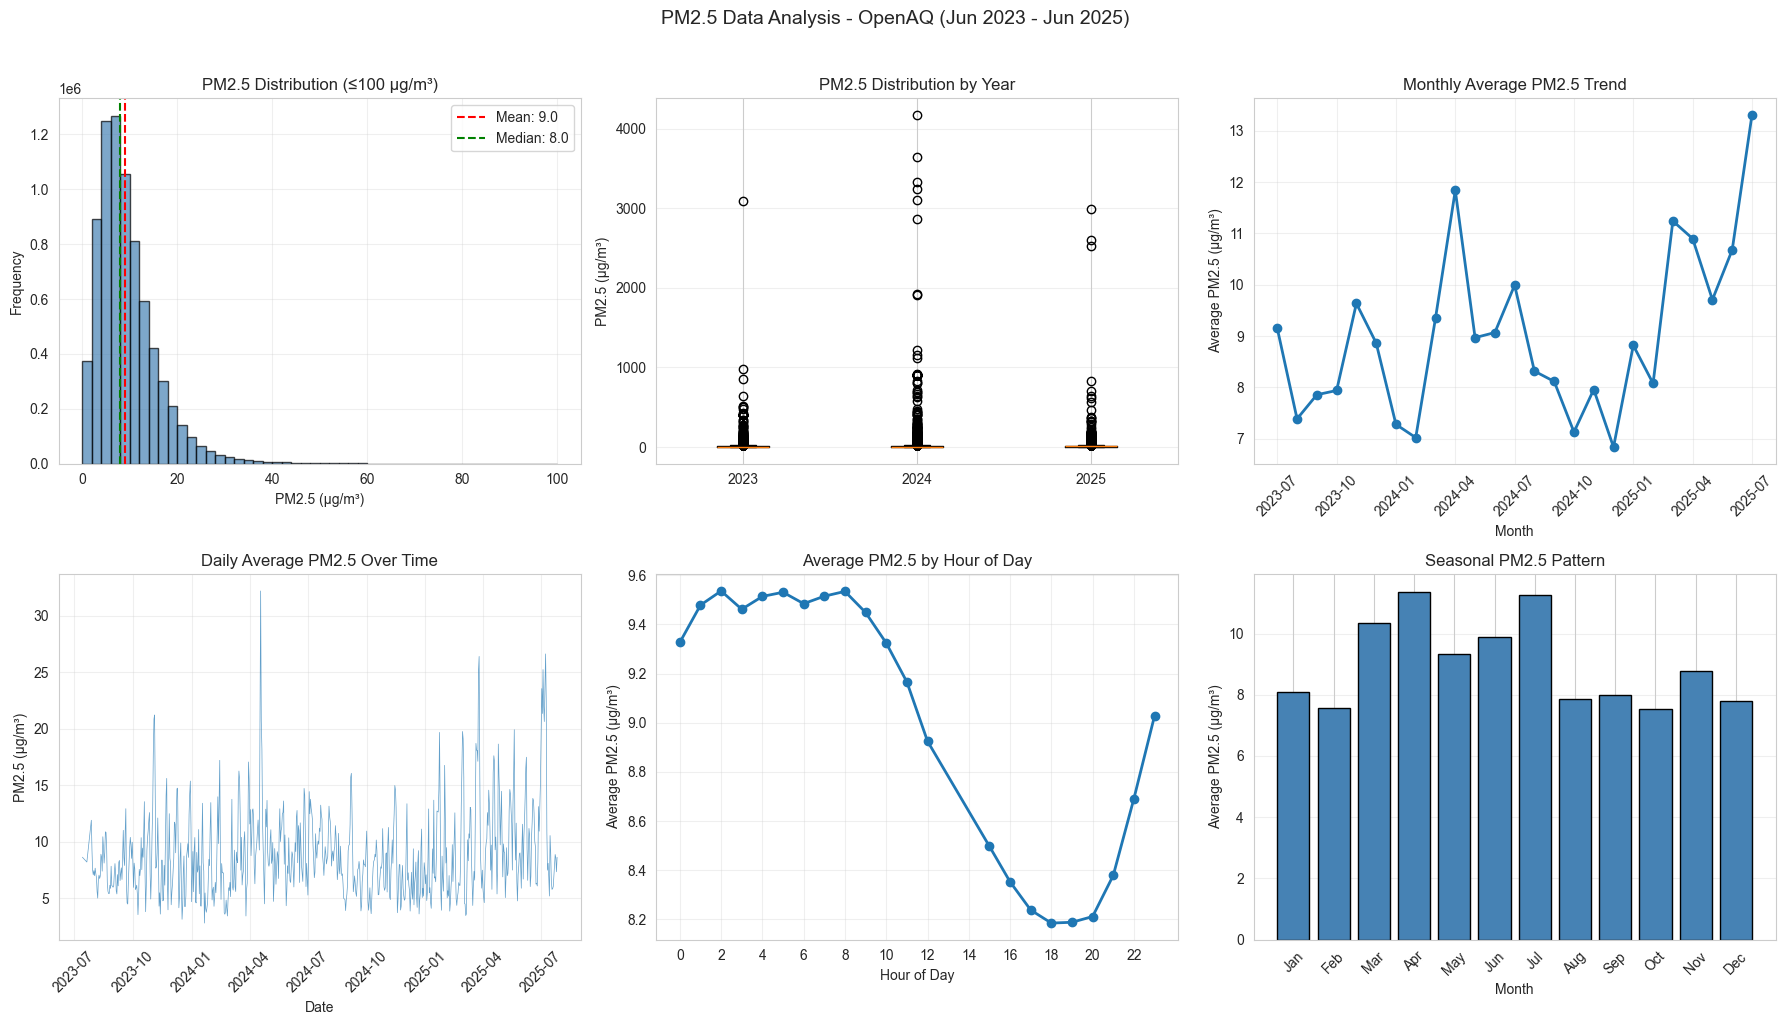

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

pm25_mean = df['pm25_ugm3_mean'].dropna()
axes[0, 0].hist(pm25_mean[pm25_mean <= 100], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('PM2.5 (μg/m³)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PM2.5 Distribution (≤100 μg/m³)')
axes[0, 0].axvline(pm25_mean.mean(), color='red', linestyle='--', label=f'Mean: {pm25_mean.mean():.1f}')
axes[0, 0].axvline(pm25_mean.median(), color='green', linestyle='--', label=f'Median: {pm25_mean.median():.1f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot([df[df['year'] == year]['pm25_ugm3_mean'].dropna() for year in [2023, 2024, 2025]], 
                   labels=['2023', '2024', '2025'])
axes[0, 1].set_ylabel('PM2.5 (μg/m³)')
axes[0, 1].set_title('PM2.5 Distribution by Year')
axes[0, 1].grid(True, alpha=0.3, axis='y')

monthly_pm25 = df.groupby(df['timestamp'].dt.to_period('M'))['pm25_ugm3_mean'].mean()
axes[0, 2].plot(range(len(monthly_pm25)), monthly_pm25.values, marker='o', linewidth=2)
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('Average PM2.5 (μg/m³)')
axes[0, 2].set_title('Monthly Average PM2.5 Trend')
axes[0, 2].set_xticks(range(0, len(monthly_pm25), 3))
axes[0, 2].set_xticklabels([str(idx) for idx in monthly_pm25.index][::3], rotation=45)
axes[0, 2].grid(True, alpha=0.3)

daily_pm25 = df.groupby('date')['pm25_ugm3_mean'].mean()
axes[1, 0].plot(daily_pm25.index, daily_pm25.values, linewidth=0.5, alpha=0.7)
axes[1, 0].set_title('Daily Average PM2.5 Over Time', fontsize=12)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('PM2.5 (μg/m³)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

hourly_pm25 = df.groupby(df['timestamp'].dt.hour)['pm25_ugm3_mean'].mean()
axes[1, 1].plot(hourly_pm25.index, hourly_pm25.values, marker='o', linewidth=2, markersize=6)
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Average PM2.5 (μg/m³)')
axes[1, 1].set_title('Average PM2.5 by Hour of Day')
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].grid(True, alpha=0.3)

seasonal_pm25 = df.groupby(df['timestamp'].dt.month)['pm25_ugm3_mean'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 2].bar(seasonal_pm25.index, seasonal_pm25.values, color='steelblue', edgecolor='black')
axes[1, 2].set_xlabel('Month')
axes[1, 2].set_ylabel('Average PM2.5 (μg/m³)')
axes[1, 2].set_title('Seasonal PM2.5 Pattern')
axes[1, 2].set_xticks(range(1, 13))
axes[1, 2].set_xticklabels(month_names, rotation=45)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('PM2.5 Data Analysis - OpenAQ (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Geographic Coverage

In [9]:
hex_locations = df[['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8']].drop_duplicates()
print(f"Geographic Coverage:")
print("="*60)
print(f"Unique hexagons: {len(hex_locations):,}")
print(f"Latitude range: {hex_locations['h3_lat_res8'].min():.2f} to {hex_locations['h3_lat_res8'].max():.2f}")
print(f"Longitude range: {hex_locations['h3_lon_res8'].min():.2f} to {hex_locations['h3_lon_res8'].max():.2f}")

hex_data_counts = df.groupby('h3_index_res8').agg({
    'pm25_ugm3_mean': ['count', 'mean', lambda x: x.notna().mean()],
    'timestamp': ['min', 'max']
}).reset_index()
hex_data_counts.columns = ['h3_index_res8', 'record_count', 'pm25_mean', 'pm25_coverage', 'first_date', 'last_date']
hex_with_counts = hex_locations.merge(hex_data_counts, on='h3_index_res8')

print(f"\nRecords per hexagon:")
print(f"  Mean: {hex_with_counts['record_count'].mean():.0f}")
print(f"  Median: {hex_with_counts['record_count'].median():.0f}")
print(f"  Min: {hex_with_counts['record_count'].min()}")
print(f"  Max: {hex_with_counts['record_count'].max()}")

print(f"\nPM2.5 data completeness per hexagon:")
print(f"  Mean: {hex_with_counts['pm25_coverage'].mean():.1%}")
print(f"  Median: {hex_with_counts['pm25_coverage'].median():.1%}")

Geographic Coverage:
Unique hexagons: 643
Latitude range: 24.34 to 45.12
Longitude range: 124.16 to 144.37

Records per hexagon:
  Mean: 11916
  Median: 15066
  Min: 0
  Max: 15910

PM2.5 data completeness per hexagon:
  Mean: 79.4%
  Median: 96.8%


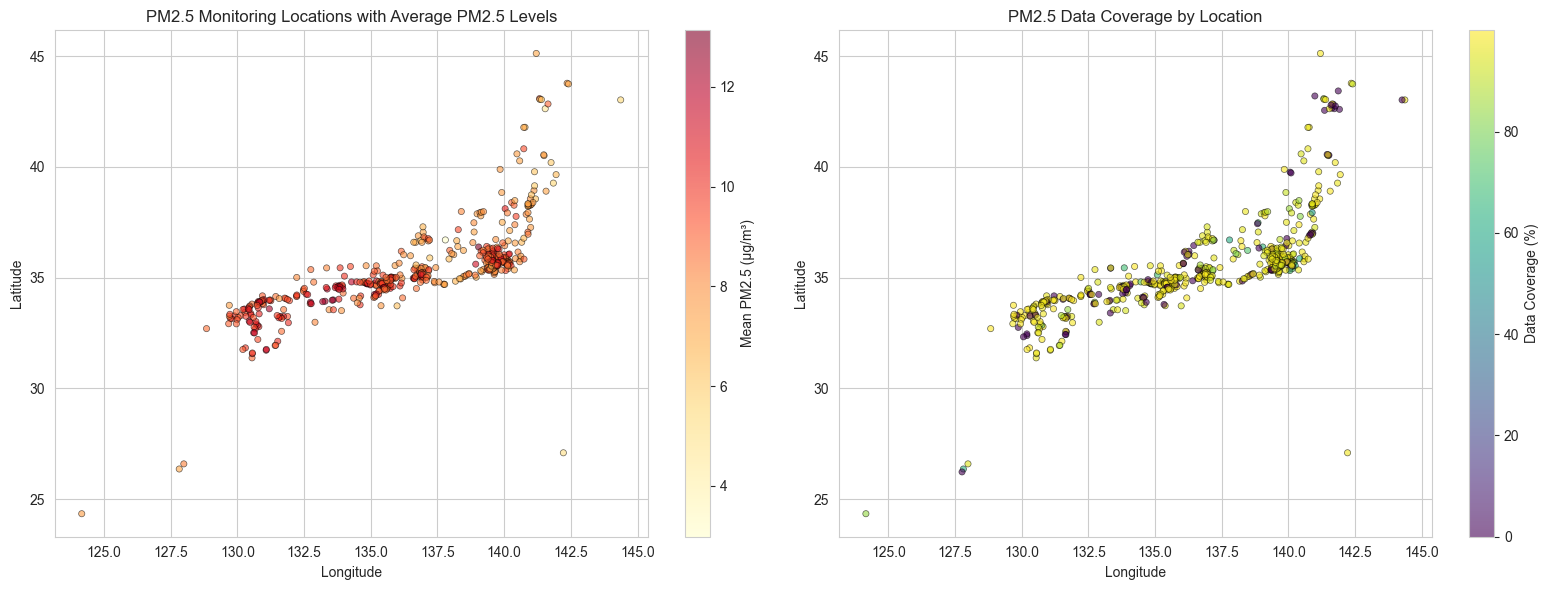

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(hex_with_counts['h3_lon_res8'],
                         hex_with_counts['h3_lat_res8'],
                         c=hex_with_counts['pm25_mean'],
                         cmap='YlOrRd', s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('PM2.5 Monitoring Locations with Average PM2.5 Levels')
plt.colorbar(scatter, ax=axes[0], label='Mean PM2.5 (μg/m³)')

scatter2 = axes[1].scatter(hex_with_counts['h3_lon_res8'],
                          hex_with_counts['h3_lat_res8'],
                          c=hex_with_counts['pm25_coverage']*100,
                          cmap='viridis', s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('PM2.5 Data Coverage by Location')
plt.colorbar(scatter2, ax=axes[1], label='Data Coverage (%)')

plt.tight_layout()
plt.show()

## 5. Yearly Comparison

In [11]:
yearly_stats = df.groupby('year').agg({
    'pm25_ugm3_mean': ['count', 'mean', 'std', 'min', 'max', lambda x: x.quantile(0.25), 
                       lambda x: x.quantile(0.50), lambda x: x.quantile(0.75), lambda x: x.quantile(0.95)]
})
yearly_stats.columns = ['Count', 'Mean', 'Std', 'Min', 'Max', 'Q25', 'Median', 'Q75', 'P95']

print("Yearly PM2.5 Statistics:")
print("="*60)
display(yearly_stats)

Yearly PM2.5 Statistics:


,Count,Mean,Std,Min,Max,Q25,Median,Q75,P95
year,,,,,,,,,
2023,1637288,8.32,6.59,0.00,3089.00,4.00,7.00,11.00,19.00
2024,3819099,8.51,8.11,0.00,4170.00,4.00,7.00,11.00,19.00
2025,2205307,10.34,8.51,0.00,2985.00,5.00,9.00,14.00,25.00


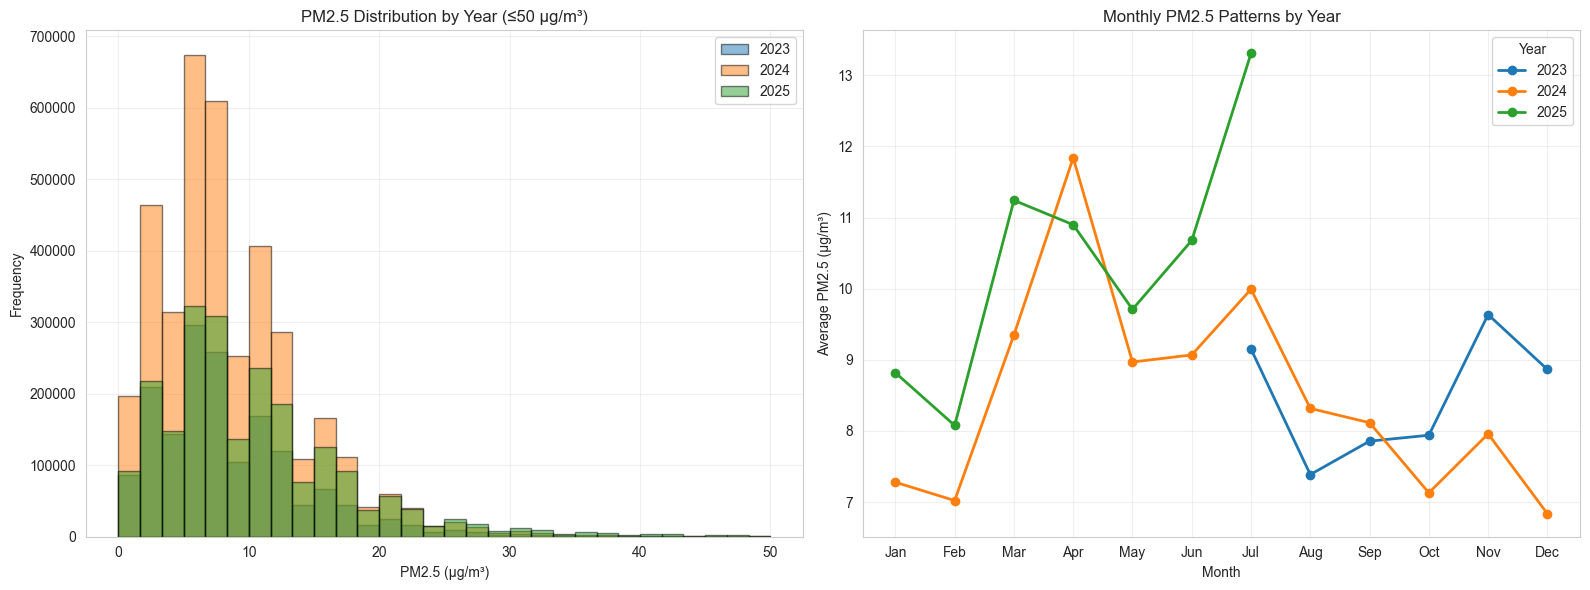

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for year in [2023, 2024, 2025]:
    year_data = df[df['year'] == year]['pm25_ugm3_mean'].dropna()
    axes[0].hist(year_data[year_data <= 50], bins=30, alpha=0.5, label=str(year), edgecolor='black')

axes[0].set_xlabel('PM2.5 (μg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('PM2.5 Distribution by Year (≤50 μg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

yearly_monthly = df.groupby(['year', 'month'])['pm25_ugm3_mean'].mean().unstack(level=0)
yearly_monthly.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average PM2.5 (μg/m³)')
axes[1].set_title('Monthly PM2.5 Patterns by Year')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].legend(title='Year')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Statistical Summary

In [13]:
print("PM2.5 Statistical Summary (Full Dataset):")
print("="*60)
display(df[pm25_columns].describe())

PM2.5 Statistical Summary (Full Dataset):


,pm25_ugm3_mean,pm25_ugm3_std,pm25_ugm3_min,pm25_ugm3_max,pm25_ugm3_count
count,7661694.00,20279.00,7661694.00,7661694.00,9579181.00
mean,9.00,2.99,8.99,9.00,0.80
std,7.98,2.70,7.98,7.98,0.40
min,0.00,0.00,0.00,0.00,0.00
25%,5.00,0.71,5.00,5.00,1.00
50%,8.00,2.12,8.00,8.00,1.00
75%,12.00,4.24,12.00,12.00,1.00
max,4170.00,81.32,4170.00,4170.00,2.00


In [ ]:
print("OPENAQ EXTENDED DATASET SUMMARY (Jun 2023 - Jun 2025)")
print("="*60)

print("\n📊 DATASET OVERVIEW:")
print(f"   Total records: {len(df):,}")
print(f"   Time period: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"   Unique locations (hexagons): {df['h3_index_res8'].nunique()}")
print(f"   Temporal resolution: Hourly")

print("\n📅 TEMPORAL COVERAGE:")
print(f"   Days with data: {len(existing_dates)}/{len(all_dates)} ({len(existing_dates)/len(all_dates)*100:.1f}%)")
print(f"   Data period: {(df['timestamp'].max() - df['timestamp'].min()).days} days")

print("\n📈 PM2.5 STATISTICS:")
pm25_clean = df['pm25_ugm3_mean'].dropna()
print(f"   Mean: {pm25_clean.mean():.2f} μg/m³")
print(f"   Median: {pm25_clean.median():.2f} μg/m³")
print(f"   Std Dev: {pm25_clean.std():.2f} μg/m³")
print(f"   Min: {pm25_clean.min():.2f} μg/m³")
print(f"   Max: {pm25_clean.max():.2f} μg/m³")
print(f"   95th percentile: {pm25_clean.quantile(0.95):.2f} μg/m³")

print("\n✅ DATA COMPLETENESS:")
for col in pm25_columns:
    completeness = df[col].notna().mean() * 100
    print(f"   {col}: {completeness:.1f}%")

print("\n🔍 KEY FINDINGS:")
missing_periods = []
if len(missing_dates) > 0:
    consecutive_missing = []
    for i, date in enumerate(missing_dates):
        if i == 0 or (missing_dates[i] - missing_dates[i-1]).days > 1:
            if consecutive_missing:
                missing_periods.append((consecutive_missing[0], consecutive_missing[-1]))
            consecutive_missing = [date]
        else:
            consecutive_missing.append(date)
    if consecutive_missing:
        missing_periods.append((consecutive_missing[0], consecutive_missing[-1]))

if missing_periods:
    print(f"   Missing data periods:")
    for start, end in missing_periods[:5]:
        print(f"     - {start} to {end} ({(end - start).days + 1} days)")
    if len(missing_periods) > 5:
        print(f"     ... and {len(missing_periods) - 5} more periods")
else:
    print(f"   ✓ Complete temporal coverage for the analysis period")

OPENAQ EXTENDED DATASET SUMMARY (Jun 2023 - Jun 2025)

📊 DATASET OVERVIEW:
   Total records: 9,579,181
   Time period: 2023-07-14 to 2025-07-26
   Unique locations (hexagons): 643
   Temporal resolution: Hourly

📅 TEMPORAL COVERAGE:
   Days with data: 732/761 (96.2%)
   Data period: 742 days

📈 PM2.5 STATISTICS:
   Mean: 9.00 μg/m³
   Median: 8.00 μg/m³
   Std Dev: 7.98 μg/m³
   Min: 0.00 μg/m³
   Max: 4170.00 μg/m³
   95th percentile: 21.00 μg/m³

✅ DATA COMPLETENESS:
   pm25_ugm3_mean: 80.0%
   pm25_ugm3_std: 0.2%
   pm25_ugm3_min: 80.0%
   pm25_ugm3_max: 80.0%
   pm25_ugm3_count: 100.0%

🔍 KEY FINDINGS:
   Missing data periods:
     - 2023-06-01 to 2023-07-13 (43 days)
     - 2023-07-15 to 2023-07-20 (6 days)
     - 2023-07-22 to 2023-07-26 (5 days)
     - 2024-02-01 to 2024-02-01 (1 days)


: 